- What does the overall salary distribution look like?
- Which job roles command the highest average salary?
- Which cities offer the highest average salary?
- Which are the top 5 companies offering the highest average salary?
- Which are the top 5 companies with salaries reported more than 20 times?
- Is there a measurable relationship between company rating and salary?
- How does employment status (e.g., Full-time vs. Contract) affect salary?
- Which job roles are most common in this dataset?
- How significantly do salaries vary across different geographic locations?


# The salary dataset

### Import required libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("default")
sns.set_context("notebook", font_scale=1.2)

%matplotlib inline


### Load Dataset

In [2]:
df = pd.read_csv("Salary_Dataset_DSL.csv")
df.head()

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android


In [4]:
df.shape

(22770, 8)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22770 entries, 0 to 22769
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             22770 non-null  float64
 1   Company Name       22769 non-null  object 
 2   Job Title          22770 non-null  object 
 3   Salary             22770 non-null  int64  
 4   Salaries Reported  22770 non-null  int64  
 5   Location           22770 non-null  object 
 6   Employment Status  22770 non-null  object 
 7   Job Roles          22770 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 1.4+ MB


In [7]:
df.describe(include="all")

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
count,22770.000000,22769,22770,2.277000e+04,22770.000000,22770,22770,22770
unique,NaN,11260,1080,NaN,NaN,10,4,11
top,NaN,Tata Consultancy Services,Software Development Engineer,NaN,NaN,Bangalore,Full Time,SDE
freq,NaN,271,2351,NaN,NaN,8264,20083,8183
mean,3.918213,NaN,NaN,6.953872e+05,1.855775,NaN,NaN,NaN
std,0.519675,NaN,NaN,8.843990e+05,6.823668,NaN,NaN,NaN
min,1.000000,NaN,NaN,2.112000e+03,1.000000,NaN,NaN,NaN
25%,3.700000,NaN,NaN,3.000000e+05,1.000000,NaN,NaN,NaN
50%,3.900000,NaN,NaN,5.000000e+05,1.000000,NaN,NaN,NaN
75%,4.200000,NaN,NaN,9.000000e+05,1.000000,NaN,NaN,NaN


### Data Cleaning

In [8]:
df.isna().sum()

Rating               0
Company Name         1
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [9]:
df.dropna(inplace=True)

In [12]:
df = df.drop_duplicates()
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


### Outlier Detection & Removal

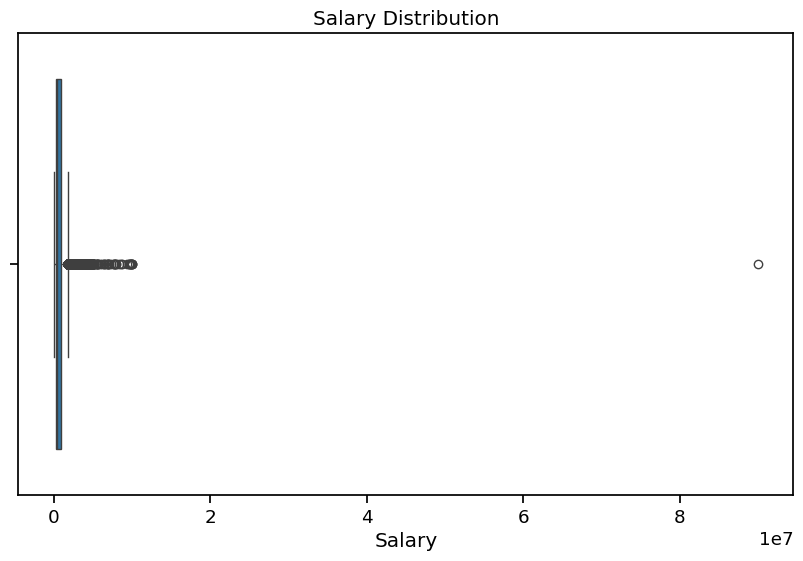

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Salary", data=df)
plt.title("Salary Distribution")
plt.show()

In [16]:
# IQR method to detect outliers
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]
outliers

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
96,4.1,Dunzo,Android Developer,2800000,1,Bangalore,Full Time,Android
106,4.0,Walmart Global Tech,Android Developer,2300000,1,Bangalore,Full Time,Android
145,4.1,First Student,Android Developer - Intern,2200000,1,Bangalore,Intern,Android
161,4.4,Microsoft,Android Developer,2100000,1,Bangalore,Full Time,Android
162,3.7,Paytm Money,Android Developer,1900000,1,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22241,3.9,Western Digital,Web Developer,2400000,1,Bangalore,Full Time,Web
22271,4.1,HealthGraph India,Web Developer,4400000,1,Bangalore,Full Time,Web
22274,2.9,Sud Express,Web Developer,2900000,1,Bangalore,Full Time,Web
22366,4.2,Greytip,Web Developer,2100000,1,Bangalore,Full Time,Web


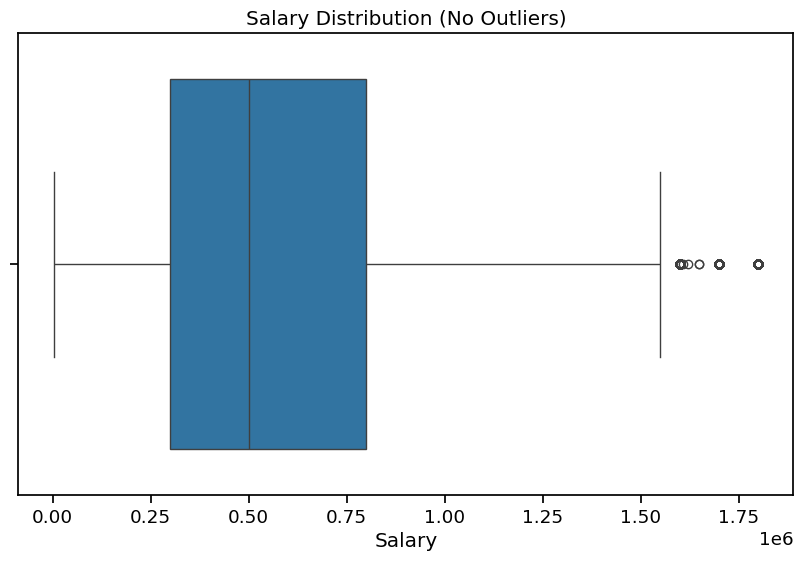

In [17]:
df_no_outliers = df[(df["Salary"] >= lower_bound) & (df["Salary"] <= upper_bound)]
plt.figure(figsize=(10, 6))
sns.boxplot(x="Salary", data=df_no_outliers)
plt.title("Salary Distribution (No Outliers)")
plt.show()

### Univariate Analysis

In [18]:
df = df_no_outliers

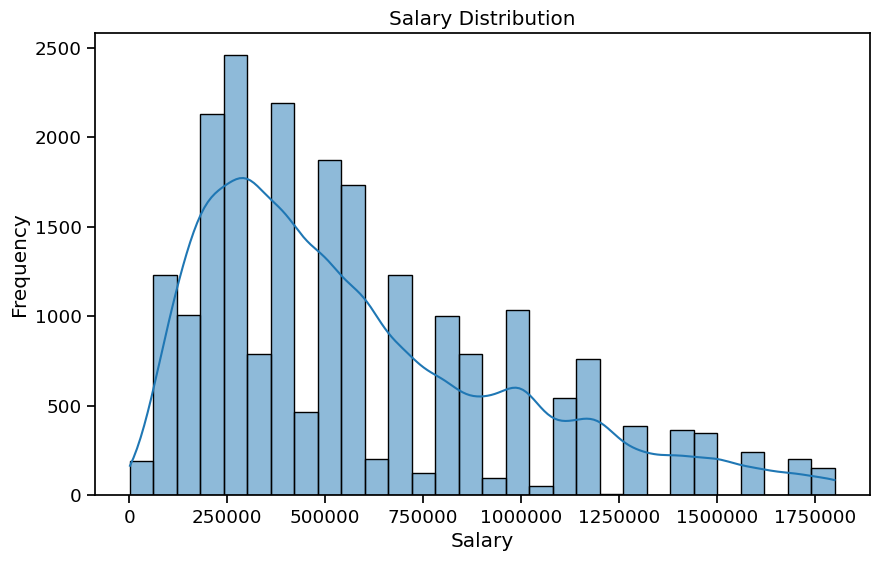

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df["Salary"], bins=30, kde=True)
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ticklabel_format(style="plain", axis="x")
plt.ylabel("Frequency")
plt.show()